<a href="https://colab.research.google.com/github/WanjaWhoopie/ABDN-Fellowship/blob/main/ERP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SESSION 9: COMPUTING & VISUALIZING ERP COMPONENTS**

In [ ]:
!pip install mne

In [ ]:
# Setup
import mne
import matplotlib.pyplot as plt

mne.set_log_level('WARNING')

In [ ]:
# Load the MNE sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_fname, preload=True)
raw.pick_types(meg=False, eeg=True, eog=True, stim=True)
raw.notch_filter(60)

<Raw | sample_audvis_raw.fif, 69 x 166800 (277.7 s), ~90.8 MiB, data loaded>

In [ ]:
# Extract Events
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'Auditory/Left': 1, 'Auditory/Right': 2,
              'Visual/Left': 3, 'Visual/Right': 4}

# Compute the ERP

TASK 1:
1. Define the Epochs.
We want to look at the visual response.
2. Set the epoch window from 200ms BEFORE the stimulus to 500ms AFTER.
3. Apply proper baseline correction to center the data at t=0.
4. Compute the Evoked Average (The ERP).
An ERP is simply the trial-averaged epoch data.

In [ ]:
# Task 1: Construct epochs and obtain evoked average
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2,
    tmax=0.5,
    baseline=(None, 0),
    preload=True,
    reject=dict(eeg=150e-6)
)

In [ ]:
#  Evoked average
erp_vis_left = epochs['Visual/Left'].average()

erp_aud_left = epochs['Auditory/Left'].average()

## Spatial Topography
TASK 2:
1. Plot the joint topographies for the Visual condition.
2. Identify the times where the P1, N1, and P2 components likely occur.

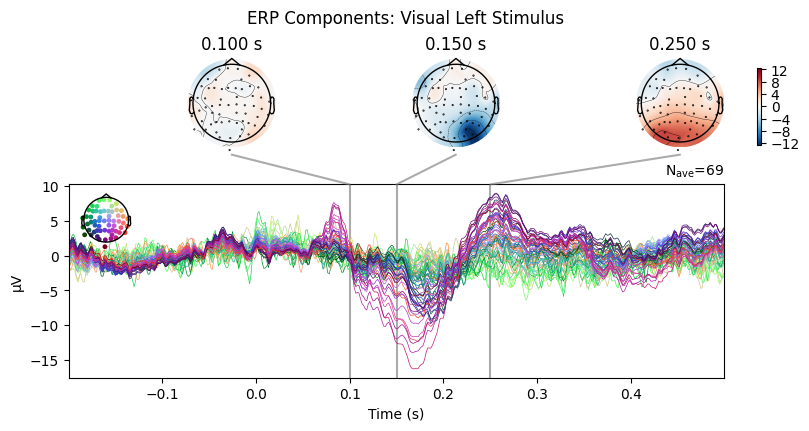

In [ ]:
# Task 2: Plot
fig = erp_vis_left.plot_joint(
    times=[0.100, 0.150, 0.250],
    title='ERP Components: Visual Left Stimulus',
    show=False
)
plt.show()

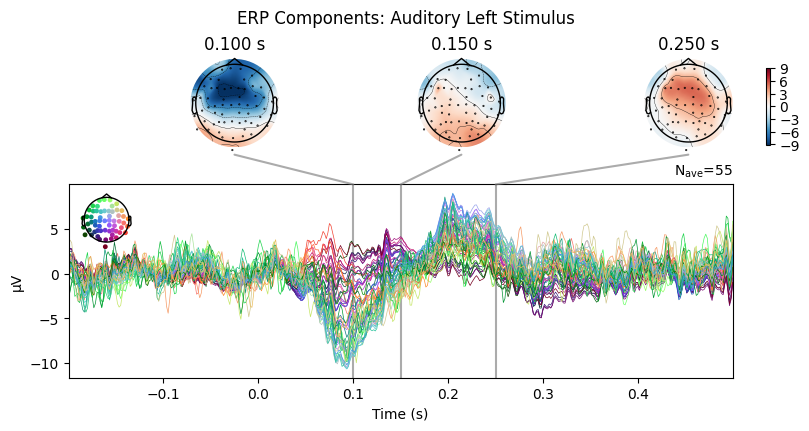

In [ ]:
# Auditory Left
fig = erp_aud_left.plot_joint(
    times=[0.100, 0.150, 0.250],
    title='ERP Components: Auditory Left Stimulus',
    show=False
)
plt.show()

## Programmatic peak extraction
TASK 3:
1. We suspect an N1 component occurs between 100ms and 200ms.
2. Instead of guessing visually, use MNE to find the exact peak latency and amplitude within this time window for the 'EEG 059' channel (Occipital).

In [ ]:
# Task 3: Peak extraction
# Find the peak for the N1 component (neg or pos)
ch_name, latency, amplitude = erp_vis_left.get_peak(
    ch_type='eeg',
    tmin=0.100,
    tmax=0.200,
    mode='neg',
    return_amplitude=True
)

print(f"N1 Peak found at channel {ch_name}: \nLatency = {latency*1000} ms, \nAmplitude = {amplitude*1e6:.2f} µV")

N1 Peak found at channel EEG 056: 
Latency = 168.16097107497646 ms, 
Amplitude = -16.30 µV


In [ ]:
ch_name, latency, amplitude = erp_vis_left.get_peak(
    ch_type='eeg',
    tmin=0.150,
    tmax=0.250,
    mode='pos',
    return_amplitude=True
)

print(f"P2 Peak found at channel {ch_name}: \nLatency = {latency*1000} ms, \nAmplitude = {amplitude*1e6:.2f} µV")

P2 Peak found at channel EEG 057: 
Latency = 249.74401644798482 ms, 
Amplitude = 8.37 µV


## Contrasting Conditions
TASK 4:
1. Compare the Visual and Auditory responses at a central electrode (EEG 021).
2. ERPs are most valuable when contrasting conditions.

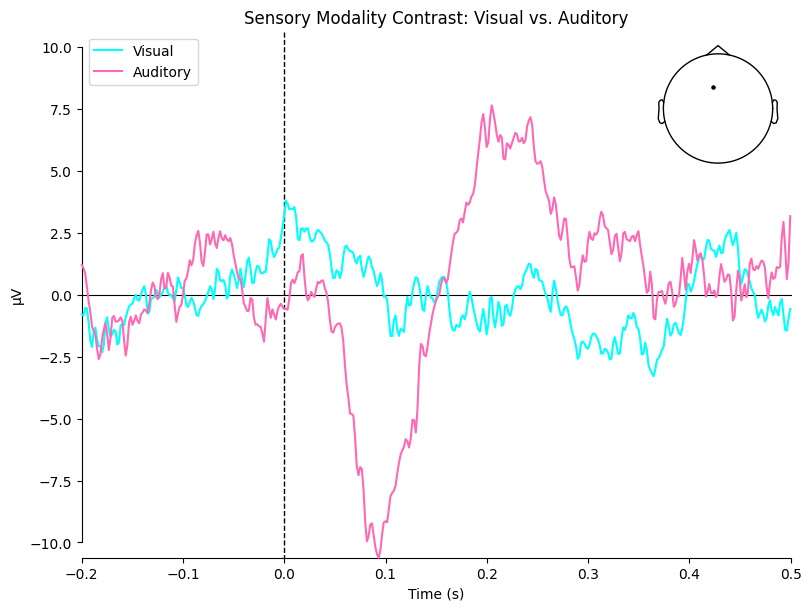

[<Figure size 800x600 with 2 Axes>]

In [ ]:
# Task 4
# Create a dictionary of our evokeds
evokeds_dict = {
    'Visual': erp_vis_left,
    'Auditory': erp_aud_left
}

# Plot the comparison
mne.viz.plot_compare_evokeds(
    evokeds_dict,
    picks='EEG 012',
    title='Sensory Modality Contrast: Visual vs. Auditory',
    colors={'Visual': 'cyan', 'Auditory': 'hotpink'},
    show_sensors=True
)